## Сверточные нейронные сети (CNN). Компьютерное зрение. Задача классификации изображений

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

### Обучение своей собственной модели
Загрузка датасета для классификации кошек и собак.

In [2]:
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cats_and_dogs", 
    validation_split=0.2, 
    subset="both", 
    seed=81, 
    image_size=(200,400), 
    batch_size=32,
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Using 400 files for validation.


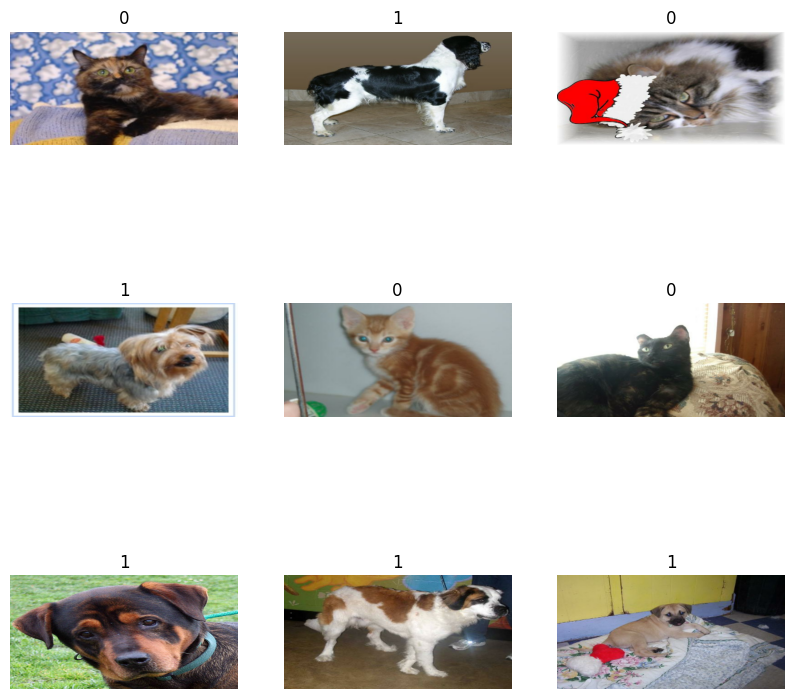

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

Аугментация

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomBrightness(0.2)
    ]
)

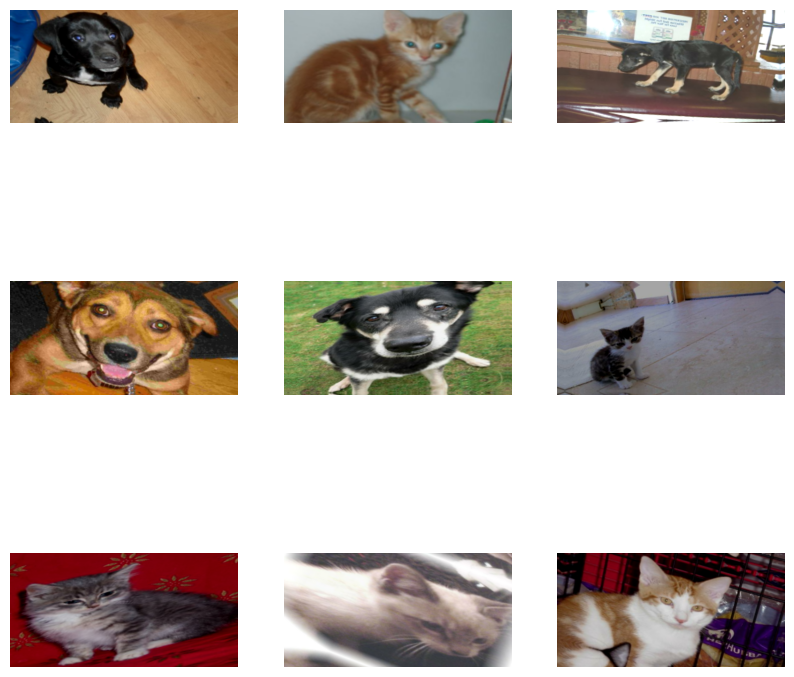

In [5]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

Сборка CNN с помощью TensorFlow и решение задачи классификации кошек и собак.

In [6]:
inputs = tf.keras.Input(shape=(200, 400, 3))

x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)

x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)

outputs = tf.keras.layers.Dense(2, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

In [7]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 400, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 200, 400, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 200, 400, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 100, 200, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 200, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 50, 100, 64)       0         
 g2D)                                                        

In [8]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

In [9]:
model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
50/50 [==============================] - 28s 556ms/step - loss: 0.9043 - accuracy: 0.5063 - val_loss: 0.6906 - val_accuracy: 0.5150
Epoch 2/10
50/50 [==============================] - 27s 547ms/step - loss: 0.6642 - accuracy: 0.6131 - val_loss: 0.6768 - val_accuracy: 0.6175
Epoch 3/10
50/50 [==============================] - 27s 548ms/step - loss: 0.5824 - accuracy: 0.7044 - val_loss: 0.6575 - val_accuracy: 0.6325
Epoch 4/10
50/50 [==============================] - 27s 546ms/step - loss: 0.4916 - accuracy: 0.7606 - val_loss: 0.6708 - val_accuracy: 0.6650
Epoch 5/10
50/50 [==============================] - 28s 552ms/step - loss: 0.3803 - accuracy: 0.8369 - val_loss: 0.8326 - val_accuracy: 0.6475
Epoch 6/10
50/50 [==============================] - 28s 561ms/step - loss: 0.2356 - accuracy: 0.8994 - val_loss: 0.8588 - val_accuracy: 0.6550
Epoch 7/10
50/50 [==============================] - 28s 565ms/step - loss: 0.1464 - accuracy: 0.9506 - val_loss: 1.2989 - val_accuracy: 0.6725

In [14]:
model.save("../models/cats_and_dogs_cnn.keras")

Протестируем

![Котики](../data/cats_and_dogs/cats/0.jpg)

In [ ]:
img = tf.keras.preprocessing.image.load_img(
    "../data/cats_and_dogs/cats/0.jpg", target_size=(200, 400)
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)       

predictions = model.predict(img_array)
predictions

1/1 [==============================] - 0s 16ms/step


array([[0.9989618, 0.0010382]], dtype=float32)

Загрузим модель и протестируем на реальном фото.

![Агата](../data/cats_and_dogs/dogs/test.png)

In [ ]:
loaded_model = tf.keras.models.load_model("../models/cats_and_dogs_cnn.keras", compile=False)
loaded_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [16]:
img_test = tf.keras.preprocessing.image.load_img(
    "../data/cats_and_dogs/dogs/test.png", target_size=(200, 400)
)
img_array = tf.keras.preprocessing.image.img_to_array(img_test)
img_array = tf.expand_dims(img_array, 0)       

predictions = loaded_model.predict(img_array)
predictions = np.array(predictions)

rounded = np.round(predictions, decimals=4)
print(rounded)

1/1 [==============================] - 0s 13ms/step
[[0. 1.]]


Модель верно распозанает даже и нечеткие, и неизвестные ей изображения - хайп!⚡️

#### Вывод
1. **Вопрос**: Какие этапы предварительной обработки данных Вы выполняете и что происходит с данными?

    **Ответ**: Загрузка данных, их разделение на train и test, аугментация - создание копии исходного датасета, но в новом картинки будут повернуты, отзеркалены, приближены и с измененной яркостью.

2. **Вопрос**: Что означают параметры, которые Вы задаете? Какие слои есть в Вашей реализации CNN и что происходит на каждом слое?

    **Ответ**:

    `inputs = tf.keras.Input(shape=(200, 400, 3))` - картинка размера 200 * 400 c 3-мя цветами 

    `x = Conv2D(32, 3, padding="same", activation="relu")(x)` - в двумерном сверточном слое создается 32 ядра с размерами (3, 3), которые обучаются для нахождения закономерностей, `padding` гарантирует, что выходная картинка будет такого же размера как входная, функция активации отсекает ненужные признаки, чем вносит нелинейность

    `x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)` - сканирует полученные карты признаков окошком размера 2x2 пикселя с шагом `strides`=2 пикселя

    `x = tf.keras.layers.Flatten()(x)` - превращает многомерную матрицу признаков в одномерный вектор

    `x = tf.keras.layers.Dense(64, activation="relu")(x)` - полносвязный слой, который занимается анализом

    `outputs = tf.keras.layers.Dense(2, activation="softmax")(x)` - финальный слой, который формулирует окончательное решение. `softmax` превращает ответ в вероятности, по которым можно определить класс, к которому относится картинка

    `model = tf.keras.Model(inputs, outputs)` - объединяем все созданные слои в один объект

### Перенос обучения (Transfer Learning) методом тонкой настройки (Fine-Tuning)

Загрузка датасета для классификации машин, банкнот и ежей.

In [28]:
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cars_dollars_hedgehogs", 
    validation_split=0.2, 
    subset="both", 
    seed=81, 
    image_size=(224,224), 
    batch_size=32,
)

Found 230 files belonging to 3 classes.
Using 184 files for training.
Using 46 files for validation.


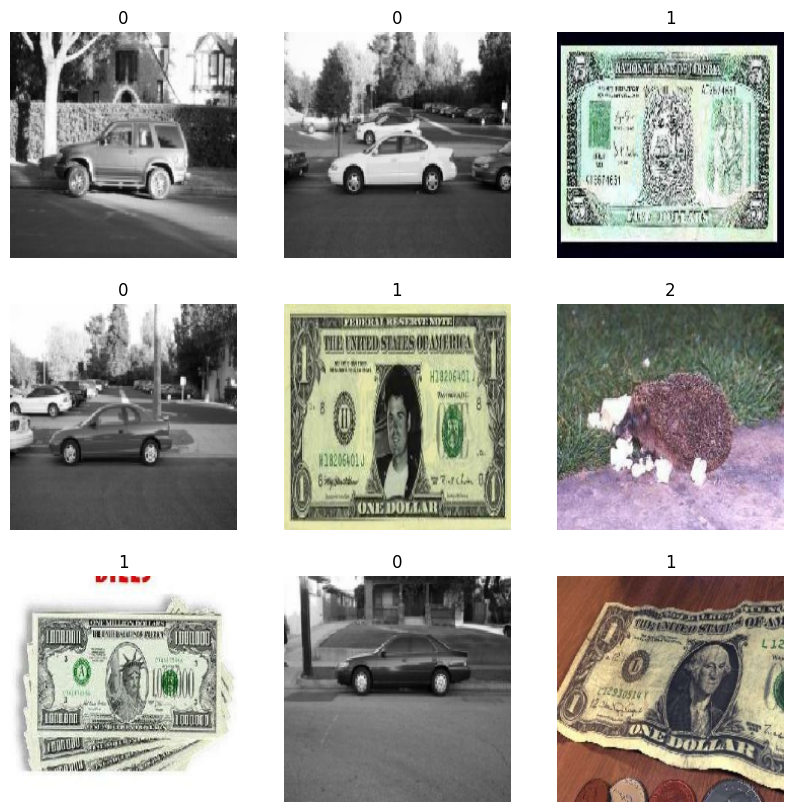

In [29]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

Аугментация

In [30]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomBrightness(0.2)
    ]
)

#### Модель VGG19

In [ ]:
vgg = tf.keras.applications.VGG19(weights='imagenet', include_top=True)
vgg.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

Создадим новый слой, который будет возвращать вероятности трех рассматриваемых классов, заменим предпоследни слой на свой

In [32]:
vgg_input = vgg.input

new_classification_layer_vgg = tf.keras.layers.Dense(3, activation='softmax')
vgg_out = new_classification_layer_vgg(vgg.layers[-2].output)

vgg_new = tf.keras.Model(vgg_input, vgg_out)

Теперь на выходе три нейрона

In [33]:
vgg_new.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

Дообучим только последний слой

In [ ]:
for layer in vgg_new.layers:
    layer.trainable = False    
vgg_new.layers[-1].trainable = True

In [35]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
vgg_new.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

In [36]:
vgg_new.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10


6/6 [==============================] - 18s 3s/step - loss: 0.4777 - accuracy: 0.8043 - val_loss: 0.0014 - val_accuracy: 1.0000
Epoch 2/10
6/6 [==============================] - 18s 3s/step - loss: 0.0049 - accuracy: 1.0000 - val_loss: 2.8125e-05 - val_accuracy: 1.0000
Epoch 3/10
6/6 [==============================] - 18s 3s/step - loss: 4.9372e-04 - accuracy: 1.0000 - val_loss: 4.2421e-06 - val_accuracy: 1.0000
Epoch 4/10
6/6 [==============================] - 18s 3s/step - loss: 1.9930e-04 - accuracy: 1.0000 - val_loss: 1.5938e-06 - val_accuracy: 1.0000
Epoch 5/10
6/6 [==============================] - 17s 3s/step - loss: 1.4017e-04 - accuracy: 1.0000 - val_loss: 9.6921e-07 - val_accuracy: 1.0000
Epoch 6/10
6/6 [==============================] - 18s 3s/step - loss: 1.1157e-04 - accuracy: 1.0000 - val_loss: 7.5930e-07 - val_accuracy: 1.0000
Epoch 7/10
6/6 [==============================] - 18s 3s/step - loss: 8.3240e-05 - accuracy: 1.0000 - val_loss: 6.7638e-07 - val_accuracy: 1.0000
E

Протестируем

![Еж](../data/cars_dollars_hedgehogs/hedgehog/test.png)

In [ ]:
vgg_new.save("../models/cars_dollars_hedgehods_vgg19.keras")

img = tf.keras.preprocessing.image.load_img(
    "../data/cars_dollars_hedgehogs/hedgehog/test.png", target_size=(224, 224)
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)       

predictions = vgg_new.predict(img_array)
probabilities = predictions[0] * 100

rounded = np.round(probabilities, decimals=4)
print(f"Вероятность машины = {rounded[0]}%")
print(f"Вероятность банкноты = {rounded[1]}%")
print(f"Вероятность ежика = {rounded[2]}%")

1/1 [==============================] - 0s 103ms/step
Вероятность машины = 0.0%
Вероятность банкноты = 0.0%
Вероятность ежика = 100.0%


Ëжик найден!🦔

#### Модель InceptionV3

In [ ]:
inception_v3 = tf.keras.applications.InceptionV3(weights='imagenet', include_top=True) 
inception_v3.summary()

96112376/96112376 [==============================] - 87s 1us/step
Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 149, 149, 32)         864       ['input_2[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 149, 149, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activati

In [55]:
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cars_dollars_hedgehogs", 
    validation_split=0.2, 
    subset="both", 
    seed=81, 
    image_size=(299,299), 
    batch_size=32,
)

Found 230 files belonging to 3 classes.
Using 184 files for training.
Using 46 files for validation.


In [56]:
inception_input = inception_v3.input

new_classification_layer_inception = tf.keras.layers.Dense(3, activation='softmax')
inception_out = new_classification_layer_inception(inception_v3.layers[-2].output)

inception_new = tf.keras.Model(inception_input, inception_out)

In [57]:
inception_new.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 149, 149, 32)         864       ['input_2[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 149, 149, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 149, 149, 32)         0         ['batch_normalization[0]

In [58]:
for layer in inception_new.layers:
    layer.trainable = False    
inception_new.layers[-1].trainable = True

In [59]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
inception_new.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

In [60]:
inception_new.fit(train_ds, epochs=7, validation_data=test_ds)

Epoch 1/7
6/6 [==============================] - 8s 1s/step - loss: 5.5849 - accuracy: 0.5924 - val_loss: 1.0847 - val_accuracy: 0.8043
Epoch 2/7
6/6 [==============================] - 5s 925ms/step - loss: 1.8537 - accuracy: 0.7500 - val_loss: 1.0134 - val_accuracy: 0.8043
Epoch 3/7
6/6 [==============================] - 5s 925ms/step - loss: 1.0111 - accuracy: 0.8261 - val_loss: 0.2615 - val_accuracy: 0.9348
Epoch 4/7
6/6 [==============================] - 5s 926ms/step - loss: 0.9352 - accuracy: 0.8750 - val_loss: 0.4015 - val_accuracy: 0.8913
Epoch 5/7
6/6 [==============================] - 5s 924ms/step - loss: 0.6012 - accuracy: 0.8913 - val_loss: 0.2604 - val_accuracy: 0.9130
Epoch 6/7
6/6 [==============================] - 5s 932ms/step - loss: 0.4904 - accuracy: 0.9076 - val_loss: 0.0157 - val_accuracy: 1.0000
Epoch 7/7
6/6 [==============================] - 5s 926ms/step - loss: 0.3915 - accuracy: 0.9457 - val_loss: 0.0056 - val_accuracy: 1.0000


In [64]:
inception_new.fit(train_ds, epochs=3, validation_data=test_ds)

Epoch 1/3
6/6 [==============================] - 6s 984ms/step - loss: 0.2346 - accuracy: 0.9402 - val_loss: 0.0047 - val_accuracy: 1.0000
Epoch 2/3
6/6 [==============================] - 6s 968ms/step - loss: 0.2177 - accuracy: 0.9457 - val_loss: 0.0661 - val_accuracy: 0.9565
Epoch 3/3
6/6 [==============================] - 6s 957ms/step - loss: 0.2246 - accuracy: 0.9565 - val_loss: 0.0330 - val_accuracy: 0.9783


In [65]:
inception_new.save("../models/cars_dollars_hedgehods_inception_v3.keras")

img = tf.keras.preprocessing.image.load_img(
    "../data/cars_dollars_hedgehogs/hedgehog/test.png", target_size=(299, 299)
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)       

predictions = inception_new.predict(img_array)
probabilities = predictions[0] * 100

rounded = np.round(probabilities, decimals=4)
print(f"Вероятность машины = {round(float(probabilities[0]), 4)}%")
print(f"Вероятность банкноты = {round(float(probabilities[0]), 4)}%")
print(f"Вероятность ежика = {round(float(probabilities[2]), 4)}%")

1/1 [==============================] - 0s 49ms/step
Вероятность машины = 0.0001%
Вероятность банкноты = 0.0001%
Вероятность ежика = 99.7274%


Тут тоже ёжик найден!🦔